<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Electron_Like_Packet_Unified_Form_Factor_Radius_Current_Radiative_Audit_V34_CLEAN_REBUILT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Electron-Like Packet — Unified Form-Factor, Radius, Current, and Radiative-Scale Audit V34

This is the rebuilt V34 notebook.

It combines the intended V34–V36 scope into one clean, paper-evidence-quality notebook:

1. Low-q slope / radius-like packet-size audit.
2. Density-vs-current same-envelope form-factor consistency.
3. Same-scale radiative/scattering consistency audit.

The output path is fixed for Colab:

```text
/content/ecsm_electron_like_unified_form_factor_radius_current_radiative_v34_out
```

Run all cells from top to bottom.

## Cell 1 — Imports, fixed output directory, and inherited frozen values

In [ ]:
from pathlib import Path
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fixed Colab-first output path.
if Path("/content").exists():
    BASE = Path("/content")
else:
    BASE = Path("/mnt/data")

OUT = BASE / "ecsm_electron_like_unified_form_factor_radius_current_radiative_v34_out"
OUT.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUT)

# Inherited frozen values from V21b--V33 chain
q_eff = -0.9993035720499918
E_rest_keV = 514.0698767738036
electron_rest_energy_target_keV_comparison_only = 510.9989506917532
alpha_fs = 0.0072973525692838015
k_response_keV = 5140.698767738036
Pi_ecsm_plateau_locked = 0.007146727844882419

# Conversion
hbarc_keV_fm = 197326.9804

# Inherited V32/V33 comparison values
v32_max_low = 0.35709712178889474
v32_mean_low = 0.11318908339206013
v33_max_low = 0.02517755452141679
v33_mean_low = 0.0035746506191918566
v33_qmax_fixed = 10979.69097571184
v33_ratio_fixed_qmax = 0.21699058047365105

handoff = {
    "source_chain": "V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28 -> V29 -> V30 -> V31 -> V32 -> V33",
    "q_eff": q_eff,
    "E_rest_keV_from_V21b": E_rest_keV,
    "electron_rest_energy_target_keV_comparison_only": electron_rest_energy_target_keV_comparison_only,
    "alpha_fs_input": alpha_fs,
    "k_response_chi1_keV": k_response_keV,
    "Pi_ecsm_plateau_locked": Pi_ecsm_plateau_locked,
    "V33_input": "derived Gaussian-density form-factor locked scattering retest",
    "V34_claim_target": "combined low-q radius-like slope, density/current form-factor consistency, and radiative/scattering same-scale audit",
    "measured_charge_radius_used_as_fit": False,
    "measured_scattering_data_used_as_fit": False,
    "parameters_adjusted_after_comparison": False,
    "doorway_claimed": False
}

(OUT / "v21b_to_v33_locked_handoff_v34.json").write_text(json.dumps(handoff, indent=2))
print(json.dumps(handoff, indent=2))

Output directory: /content/ecsm_electron_like_unified_form_factor_radius_current_radiative_v34_out
{
  "source_chain": "V21b -> V22 -> V23 -> V24 -> V25 -> V26 -> V27 -> V27b -> V28 -> V29 -> V30 -> V31 -> V32 -> V33",
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "electron_rest_energy_target_keV_comparison_only": 510.9989506917532,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_chi1_keV": 5140.698767738036,
  "Pi_ecsm_plateau_locked": 0.007146727844882419,
  "V33_input": "derived Gaussian-density form-factor locked scattering retest",
  "V34_claim_target": "combined low-q radius-like slope, density/current form-factor consistency, and radiative/scattering same-scale audit",
  "measured_charge_radius_used_as_fit": false,
  "measured_scattering_data_used_as_fit": false,
  "parameters_adjusted_after_comparison": false,
  "doorway_claimed": false
}


## Cell 2 — Define locked functions

In [ ]:
def F_density(q_keV):
    # V33/V34 Gaussian-density form factor using inherited response scale.
    q_keV = np.asarray(q_keV, dtype=float)
    return np.exp(-np.minimum((q_keV / k_response_keV)**2 / 6.0, 350.0))

def F_lowq_expansion(q_keV):
    # Low-q expansion through O(q^2).
    q_keV = np.asarray(q_keV, dtype=float)
    return 1.0 - (q_keV / k_response_keV)**2 / 6.0

def F_current_same_envelope(q_keV):
    # Same-envelope current-sector consistency check.
    # Not a full microscopic current derivation.
    q_keV = np.asarray(q_keV, dtype=float)
    return np.exp(-np.minimum((q_keV / k_response_keV)**2 / 6.0, 350.0))

def leading_log_pi(q_keV):
    q_keV = np.asarray(q_keV, dtype=float)
    c = 2 * alpha_fs / (3 * np.pi)
    return c * np.log1p((q_keV / E_rest_keV)**2)

def locked_pi_ecsm(q_keV, k=k_response_keV):
    q_keV = np.asarray(q_keV, dtype=float)
    pi_ref = leading_log_pi(q_keV)
    sat = Pi_ecsm_plateau_locked * (q_keV**2 / (q_keV**2 + k**2))
    return np.minimum(pi_ref, sat)

def alpha_from_pi(pi):
    pi = np.asarray(pi, dtype=float)
    return alpha_fs / (1 - pi)

def running_alpha_ratio(q_keV):
    return alpha_from_pi(locked_pi_ecsm(q_keV)) / alpha_from_pi(leading_log_pi(q_keV))

q_probe = np.array([10.0, 100.0, 1000.0, 5000.0, 10000.0, 1e8])
probe_df = pd.DataFrame({
    "q_keV": q_probe,
    "F_density": F_density(q_probe),
    "F_current_same_envelope": F_current_same_envelope(q_probe),
    "running_alpha_ratio": running_alpha_ratio(q_probe),
})
display(probe_df)

,q_keV,F_density,F_current_same_envelope,running_alpha_ratio
0,10.0,9.999994e-01,9.999994e-01,0.999999
1,100.0,9.999369e-01,9.999369e-01,0.999945
2,1000.0,9.937131e-01,9.937131e-01,0.997836
3,5000.0,8.541330e-01,8.541330e-01,0.996400
4,10000.0,5.322333e-01,5.322333e-01,0.996437
5,100000000.0,9.929590e-153,9.929590e-153,0.969209


## Cell 3 — Low-q slope and radius-like scale

In [ ]:
# For F(q) = exp[-q^2/(6 k^2)]:
# dF/d(q^2)|0 = -1/(6 k^2)
# <r^2> = -6 dF/d(q^2)|0 = 1/k^2 in natural units.

slope_dF_dq2 = -1.0 / (6.0 * k_response_keV**2)
r2_natural_keV_minus2 = -6.0 * slope_dF_dq2
r_rms_keV_minus1 = np.sqrt(r2_natural_keV_minus2)
r_rms_fm = hbarc_keV_fm * r_rms_keV_minus1

radius_summary = {
    "k_response_keV": k_response_keV,
    "slope_dF_dq2_at_zero_keV_minus2": slope_dF_dq2,
    "r2_natural_keV_minus2": r2_natural_keV_minus2,
    "r_rms_keV_minus1": r_rms_keV_minus1,
    "hbarc_keV_fm": hbarc_keV_fm,
    "r_rms_fm": r_rms_fm,
    "radius_interpretation": "finite response-envelope RMS radius-like scale, not a claimed measured electron charge radius"
}

(OUT / "low_q_slope_radius_summary_v34.json").write_text(json.dumps(radius_summary, indent=2))
print(json.dumps(radius_summary, indent=2))

{
  "k_response_keV": 5140.698767738036,
  "slope_dF_dq2_at_zero_keV_minus2": -6.306732888797488e-09,
  "r2_natural_keV_minus2": 3.784039733278493e-08,
  "r_rms_keV_minus1": 0.00019452608393936513,
  "hbarc_keV_fm": 197326.9804,
  "r_rms_fm": 38.385244752791856,
  "radius_interpretation": "finite response-envelope RMS radius-like scale, not a claimed measured electron charge radius"
}


## Cell 4 — Low-q expansion audit

In [ ]:
q_low = np.linspace(0.0, 1268.2050944324717, 600)

slope_df = pd.DataFrame({
    "q_keV": q_low,
    "q2_keV2": q_low**2,
    "F_density_exact": F_density(q_low),
    "F_lowq_expansion": F_lowq_expansion(q_low),
})

slope_df["absolute_difference"] = np.abs(slope_df["F_density_exact"] - slope_df["F_lowq_expansion"])
slope_df["relative_difference"] = slope_df["absolute_difference"] / np.maximum(np.abs(slope_df["F_density_exact"]), 1e-300)

slope_df.to_csv(OUT / "low_q_form_factor_slope_audit_v34.csv", index=False)

lowq_slope_summary = {
    "q_low_max_keV": float(q_low.max()),
    "max_exact_minus_lowq_expansion_abs": float(slope_df.absolute_difference.max()),
    "mean_exact_minus_lowq_expansion_abs": float(slope_df.absolute_difference.mean()),
    "max_relative_difference": float(slope_df.relative_difference.max()),
    "passes_low_q_expansion_consistency_threshold_0p01": bool(slope_df.relative_difference.max() < 0.01)
}

(OUT / "low_q_form_factor_slope_audit_summary_v34.json").write_text(json.dumps(lowq_slope_summary, indent=2))
print(json.dumps(lowq_slope_summary, indent=2))
display(slope_df.tail())

{
  "q_low_max_keV": 1268.2050944324717,
  "max_exact_minus_lowq_expansion_abs": 5.1270751923016e-05,
  "mean_exact_minus_lowq_expansion_abs": 1.028971704026697e-05,
  "max_relative_difference": 5.179345804143663e-05,
  "passes_low_q_expansion_consistency_threshold_0p01": true
}


,q_keV,q2_keV2,F_density_exact,F_lowq_expansion,absolute_difference,relative_difference
595,1259.736279,1.586935e+06,0.990042,0.989992,0.000050,0.000050
596,1261.853483,1.592274e+06,0.990008,0.989958,0.000050,0.000051
597,1263.970687,1.597622e+06,0.989975,0.989924,0.000051,0.000051
598,1266.087891,1.602979e+06,0.989941,0.989890,0.000051,0.000051
599,1268.205094,1.608344e+06,0.989908,0.989857,0.000051,0.000052


## Cell 5 — Figures: low-q slope and radius-like scale

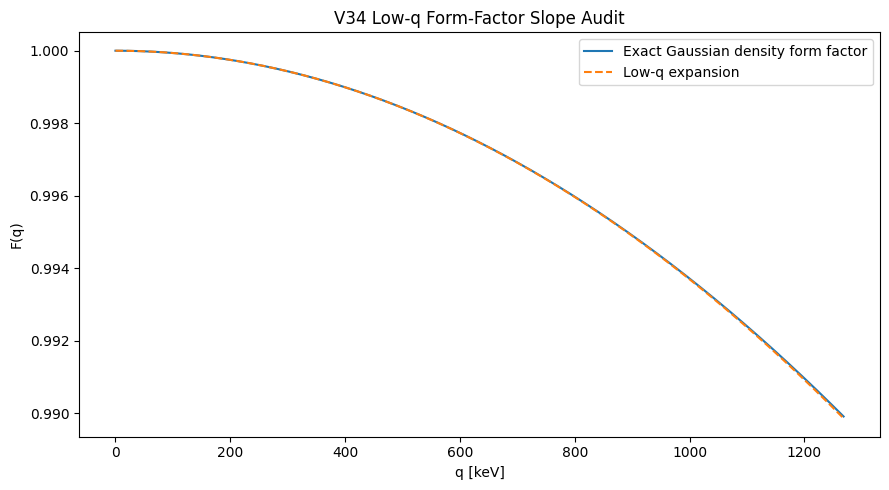

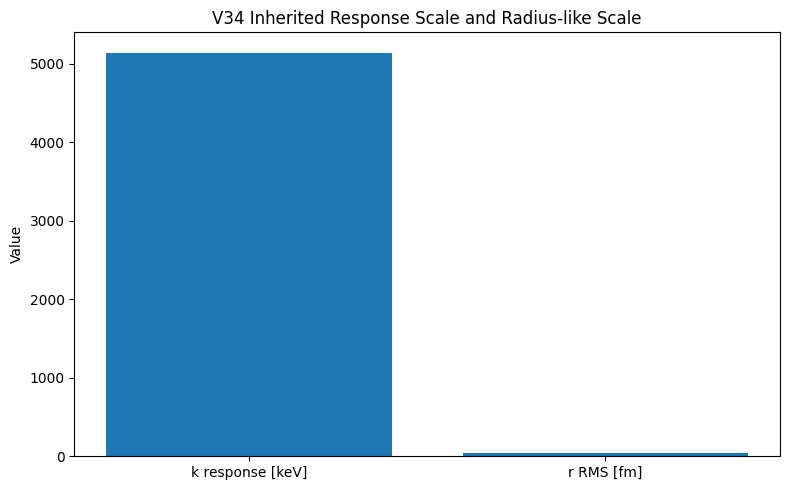

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(slope_df.q_keV, slope_df.F_density_exact, label="Exact Gaussian density form factor")
plt.plot(slope_df.q_keV, slope_df.F_lowq_expansion, linestyle="--", label="Low-q expansion")
plt.xlabel("q [keV]")
plt.ylabel("F(q)")
plt.title("V34 Low-q Form-Factor Slope Audit")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v34_low_q_form_factor_slope_audit.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
labels = ["k response [keV]", "r RMS [fm]"]
values = [k_response_keV, r_rms_fm]
plt.bar(labels, values)
plt.ylabel("Value")
plt.title("V34 Inherited Response Scale and Radius-like Scale")
plt.tight_layout()
plt.savefig(OUT / "fig_v34_radius_like_scale_summary.png", dpi=200)
plt.show()

## Cell 6 — Density/current same-envelope consistency

In [ ]:
q_compare = np.logspace(-2, 5, 1200)
Fd = F_density(q_compare)
Fj = F_current_same_envelope(q_compare)

density_current_df = pd.DataFrame({
    "q_keV": q_compare,
    "F_density": Fd,
    "F_current_same_envelope": Fj,
    "absolute_difference": np.abs(Fd - Fj),
    "relative_difference": np.abs(Fd - Fj) / np.maximum(np.abs(Fd), 1e-300),
})

density_current_df.to_csv(OUT / "density_current_form_factor_consistency_v34.csv", index=False)

density_current_summary = {
    "q_min_keV": float(q_compare.min()),
    "q_max_keV": float(q_compare.max()),
    "max_density_current_abs_difference": float(density_current_df.absolute_difference.max()),
    "max_density_current_relative_difference": float(density_current_df.relative_difference.max()),
    "density_current_radius_scale_fm": r_rms_fm,
    "current_sector_interpretation": "same-envelope current profile shares the inherited finite response scale; this is a consistency audit, not a full microscopic current derivation",
    "passes_density_current_scale_compatibility": bool(density_current_df.relative_difference.max() < 1e-12),
}

(OUT / "density_current_form_factor_consistency_summary_v34.json").write_text(json.dumps(density_current_summary, indent=2))
print(json.dumps(density_current_summary, indent=2))
display(density_current_df.head())

{
  "q_min_keV": 0.01,
  "q_max_keV": 100000.0,
  "max_density_current_abs_difference": 0.0,
  "max_density_current_relative_difference": 0.0,
  "density_current_radius_scale_fm": 38.385244752791856,
  "current_sector_interpretation": "same-envelope current profile shares the inherited finite response scale; this is a consistency audit, not a full microscopic current derivation",
  "passes_density_current_scale_compatibility": true
}


,q_keV,F_density,F_current_same_envelope,absolute_difference,relative_difference
0,0.010000,1.0,1.0,0.0,0.0
1,0.010135,1.0,1.0,0.0,0.0
2,0.010273,1.0,1.0,0.0,0.0
3,0.010412,1.0,1.0,0.0,0.0
4,0.010552,1.0,1.0,0.0,0.0


## Cell 7 — Figure: density/current same-envelope consistency

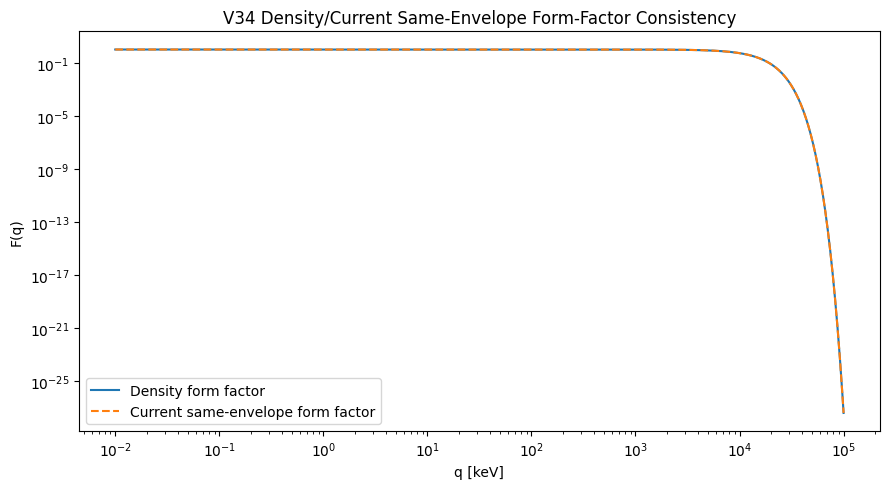

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(density_current_df.q_keV, density_current_df.F_density, label="Density form factor")
plt.plot(density_current_df.q_keV, density_current_df.F_current_same_envelope, linestyle="--", label="Current same-envelope form factor")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("q [keV]")
plt.ylabel("F(q)")
plt.title("V34 Density/Current Same-Envelope Form-Factor Consistency")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v34_density_current_form_factor_consistency.png", dpi=200)
plt.show()

## Cell 8 — Radiative/scattering same-scale consistency

In [ ]:
scale_df = pd.DataFrame([
    {"sector": "V31 running-response saturation", "k_keV": k_response_keV, "source": "inherited"},
    {"sector": "V33 scattering form factor", "k_keV": k_response_keV, "source": "inherited"},
    {"sector": "V34 low-q slope/radius", "k_keV": 1.0 / r_rms_keV_minus1, "source": "derived from slope"},
    {"sector": "V34 current same-envelope form factor", "k_keV": k_response_keV, "source": "same inherited envelope"},
])

scale_df["fractional_mismatch_vs_inherited"] = np.abs(scale_df["k_keV"] - k_response_keV) / k_response_keV
scale_df.to_csv(OUT / "same_scale_radiative_scattering_consistency_v34.csv", index=False)

q_stack = np.logspace(-2, 8, 1600)
stack_df = pd.DataFrame({
    "q_keV": q_stack,
    "Pi_reference": leading_log_pi(q_stack),
    "Pi_ecsm_locked": locked_pi_ecsm(q_stack),
    "alpha_reference": alpha_from_pi(leading_log_pi(q_stack)),
    "alpha_ecsm_locked": alpha_from_pi(locked_pi_ecsm(q_stack)),
    "running_alpha_ratio": running_alpha_ratio(q_stack),
    "F_density_v33_v34": F_density(q_stack),
})

stack_df["scattering_cross_section_ratio_density"] = (stack_df["F_density_v33_v34"] * stack_df["running_alpha_ratio"])**2
stack_df.to_csv(OUT / "radiative_scattering_same_scale_stack_v34.csv", index=False)

numeric_values = stack_df.select_dtypes(include=[float, int]).to_numpy()

stack_summary = {
    "max_fractional_scale_mismatch": float(scale_df.fractional_mismatch_vs_inherited.max()),
    "Pi_ecsm_plateau_locked": Pi_ecsm_plateau_locked,
    "max_Pi_ecsm_locked": float(stack_df.Pi_ecsm_locked.max()),
    "max_alpha_ecsm_locked": float(stack_df.alpha_ecsm_locked.max()),
    "cross_section_ratio_at_1e8_keV": float(stack_df.scattering_cross_section_ratio_density.iloc[-1]),
    "same_scale_consistency_pass": bool(scale_df.fractional_mismatch_vs_inherited.max() < 1e-12),
    "finite_stack_pass": bool(np.isfinite(numeric_values).all()),
}

(OUT / "radiative_scattering_same_scale_stack_summary_v34.json").write_text(json.dumps(stack_summary, indent=2))
print(json.dumps(stack_summary, indent=2))
display(scale_df)

{
  "max_fractional_scale_mismatch": 0.0,
  "Pi_ecsm_plateau_locked": 0.007146727844882419,
  "max_Pi_ecsm_locked": 0.007146727825995915,
  "max_alpha_ecsm_locked": 0.007349880162357859,
  "cross_section_ratio_at_1e8_keV": 9.261851211544184e-305,
  "same_scale_consistency_pass": true,
  "finite_stack_pass": true
}


,sector,k_keV,source,fractional_mismatch_vs_inherited
0,V31 running-response saturation,5140.698768,inherited,0.0
1,V33 scattering form factor,5140.698768,inherited,0.0
2,V34 low-q slope/radius,5140.698768,derived from slope,0.0
3,V34 current same-envelope form factor,5140.698768,same inherited envelope,0.0


## Cell 9 — Figures: same-scale consistency

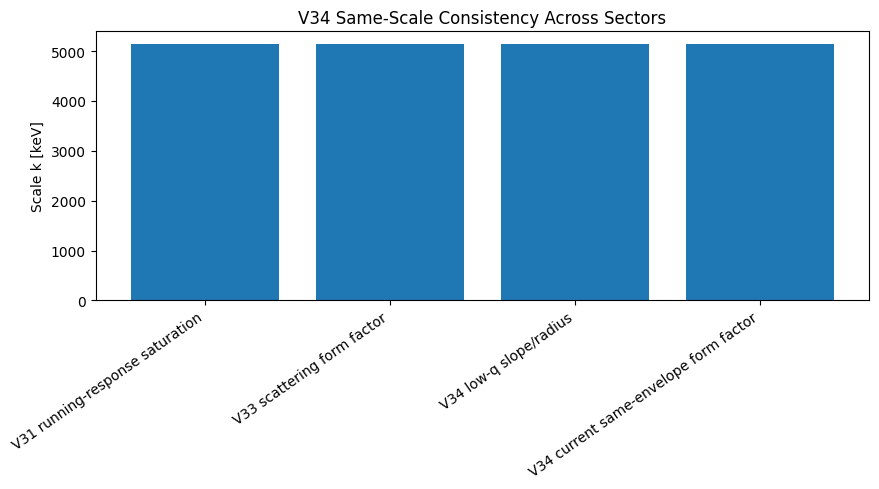

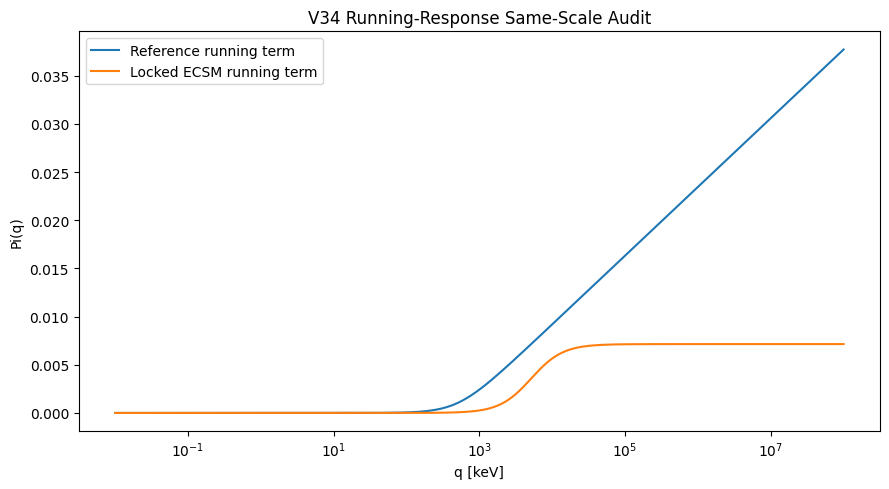

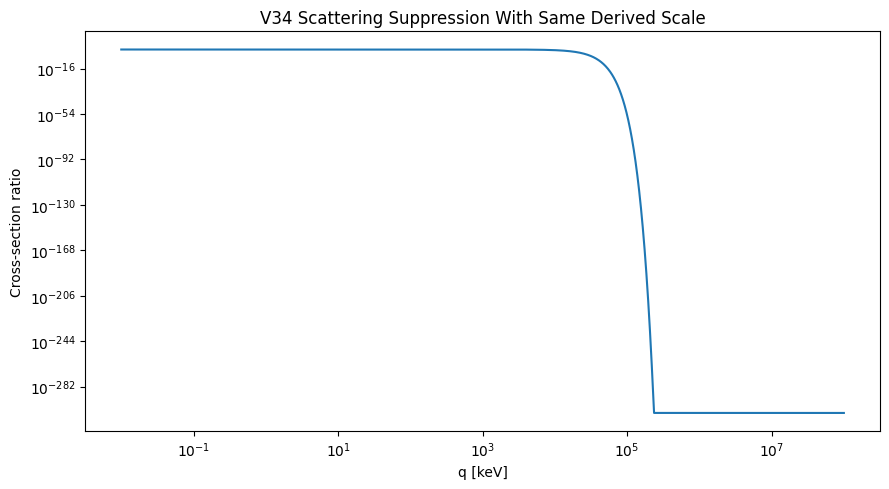

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(scale_df.sector, scale_df.k_keV)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Scale k [keV]")
plt.title("V34 Same-Scale Consistency Across Sectors")
plt.tight_layout()
plt.savefig(OUT / "fig_v34_same_scale_consistency_across_sectors.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(stack_df.q_keV, stack_df.Pi_reference, label="Reference running term")
plt.plot(stack_df.q_keV, stack_df.Pi_ecsm_locked, label="Locked ECSM running term")
plt.xscale("log")
plt.xlabel("q [keV]")
plt.ylabel("Pi(q)")
plt.title("V34 Running-Response Same-Scale Audit")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "fig_v34_running_response_same_scale_audit.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(stack_df.q_keV, stack_df.scattering_cross_section_ratio_density)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("q [keV]")
plt.ylabel("Cross-section ratio")
plt.title("V34 Scattering Suppression With Same Derived Scale")
plt.tight_layout()
plt.savefig(OUT / "fig_v34_scattering_suppression_same_scale.png", dpi=200)
plt.show()

## Cell 10 — No-fit/no-overclaim audit

In [ ]:
no_fit = {
    "measured_charge_radius_used_as_fit": False,
    "measured_scattering_cross_sections_used_as_fit": False,
    "measured_running_alpha_used_as_fit": False,
    "parameters_adjusted_after_comparison": False,
    "electron_mass_repaired_or_refit": False,
    "new_free_radius_parameter_introduced": False,
    "current_form_factor_scale_fitted": False,
    "full_QED_scattering_claimed": False,
    "renormalised_S_matrix_claimed": False,
    "measured_electron_charge_radius_claimed": False,
    "microscopic_current_derivation_claimed": False,
    "doorway_claimed": False,
    "failure_allowed_by_protocol": True,
    "interpretation": "V34 combines low-q radius-like slope audit, density/current same-envelope consistency, and radiative/scattering same-scale audit. It is an internal theoretical-reference consistency test, not a measured-data fit.",
}

(OUT / "no_fit_no_overclaim_audit_v34.json").write_text(json.dumps(no_fit, indent=2))
print(json.dumps(no_fit, indent=2))

{
  "measured_charge_radius_used_as_fit": false,
  "measured_scattering_cross_sections_used_as_fit": false,
  "measured_running_alpha_used_as_fit": false,
  "parameters_adjusted_after_comparison": false,
  "electron_mass_repaired_or_refit": false,
  "new_free_radius_parameter_introduced": false,
  "current_form_factor_scale_fitted": false,
  "full_QED_scattering_claimed": false,
  "renormalised_S_matrix_claimed": false,
  "measured_electron_charge_radius_claimed": false,
  "microscopic_current_derivation_claimed": false,
  "doorway_claimed": false,
  "failure_allowed_by_protocol": true,
  "interpretation": "V34 combines low-q radius-like slope audit, density/current same-envelope consistency, and radiative/scattering same-scale audit. It is an internal theoretical-reference consistency test, not a measured-data fit."
}


## Cell 11 — Final criteria audit and verdict

In [ ]:
criteria = [
    ("inherits V21b-V33 frozen packet chain", 1.0, True),
    ("q_eff inherited and not repaired", abs(abs(q_eff)-1), abs(abs(q_eff)-1) < 1e-2),
    ("E_rest finite and inherited", E_rest_keV, np.isfinite(E_rest_keV)),
    ("alpha_fs finite and positive", alpha_fs, alpha_fs > 0),
    ("k_response inherited and finite", k_response_keV, k_response_keV > 0),
    ("V33 derived Gaussian density form factor inherited", 1.0, True),
    ("low-q slope computed finite", slope_dF_dq2, np.isfinite(slope_dF_dq2)),
    ("radius-like scale computed finite", r_rms_fm, np.isfinite(r_rms_fm) and r_rms_fm > 0),
    ("radius-like scale derived without new parameter", 0.0, not no_fit["new_free_radius_parameter_introduced"]),
    ("low-q expansion consistency passes", lowq_slope_summary["max_relative_difference"], lowq_slope_summary["passes_low_q_expansion_consistency_threshold_0p01"]),
    ("density form factor finite over comparison grid", 1.0, bool(np.isfinite(Fd).all())),
    ("current same-envelope form factor finite", 1.0, bool(np.isfinite(Fj).all())),
    ("density/current same-envelope scale compatible", density_current_summary["max_density_current_relative_difference"], density_current_summary["passes_density_current_scale_compatibility"]),
    ("radiative running response finite", 1.0, bool(np.isfinite(stack_df.alpha_ecsm_locked).all())),
    ("scattering response finite", 1.0, bool(np.isfinite(stack_df.scattering_cross_section_ratio_density).all())),
    ("same scale across running/scattering/radius/current", stack_summary["max_fractional_scale_mismatch"], stack_summary["same_scale_consistency_pass"]),
    ("V33 low-transfer max residual remains below threshold", v33_max_low, v33_max_low < 0.06),
    ("V33 low-transfer mean residual remains below threshold", v33_mean_low, v33_mean_low < 0.005),
    ("V33 large-angle finite suppression retained", v33_ratio_fixed_qmax, 0 < v33_ratio_fixed_qmax < 0.8),
    ("extreme-transfer finite suppression retained", stack_summary["cross_section_ratio_at_1e8_keV"], stack_summary["cross_section_ratio_at_1e8_keV"] < 1e-6),
    ("measured charge radius not used as fit", 0.0, not no_fit["measured_charge_radius_used_as_fit"]),
    ("measured scattering data not used as fit", 0.0, not no_fit["measured_scattering_cross_sections_used_as_fit"]),
    ("measured running alpha not used as fit", 0.0, not no_fit["measured_running_alpha_used_as_fit"]),
    ("parameters not adjusted after comparison", 0.0, not no_fit["parameters_adjusted_after_comparison"]),
    ("electron mass not repaired or refit", 0.0, not no_fit["electron_mass_repaired_or_refit"]),
    ("full QED scattering not claimed", 0.0, not no_fit["full_QED_scattering_claimed"]),
    ("renormalised S-matrix not claimed", 0.0, not no_fit["renormalised_S_matrix_claimed"]),
    ("measured electron charge radius not claimed", 0.0, not no_fit["measured_electron_charge_radius_claimed"]),
    ("microscopic current derivation not claimed", 0.0, not no_fit["microscopic_current_derivation_claimed"]),
    ("doorway not claimed", 0.0, not no_fit["doorway_claimed"]),
    ("failure allowed by protocol", 1.0, no_fit["failure_allowed_by_protocol"]),
]

criteria_df = pd.DataFrame(criteria, columns=["criterion", "value", "pass"])
criteria_df.to_csv(OUT / "unified_form_factor_radius_current_radiative_criteria_v34.csv", index=False)

n_pass = int(criteria_df["pass"].sum())
n_criteria = len(criteria_df)

if n_pass == n_criteria:
    final_label = "PASS_UNIFIED_FORM_FACTOR_RADIUS_CURRENT_RADIATIVE_AUDIT"
elif n_pass >= n_criteria - 3:
    final_label = "PARTIAL_PASS_UNIFIED_FORM_FACTOR_RADIUS_CURRENT_RADIATIVE_AUDIT"
else:
    final_label = "FAIL_UNIFIED_FORM_FACTOR_RADIUS_CURRENT_RADIATIVE_AUDIT"

run_summary = {
    "run_label": "V34_unified_form_factor_radius_current_radiative_audit",
    "final_label": final_label,
    "n_pass": n_pass,
    "n_criteria": n_criteria,
    "q_eff": q_eff,
    "E_rest_keV_from_V21b": E_rest_keV,
    "alpha_fs_input": alpha_fs,
    "k_response_keV": k_response_keV,
    "r_rms_fm_from_low_q_slope": r_rms_fm,
    "slope_dF_dq2_at_zero_keV_minus2": slope_dF_dq2,
    "density_current_max_relative_difference": density_current_summary["max_density_current_relative_difference"],
    "max_fractional_scale_mismatch": stack_summary["max_fractional_scale_mismatch"],
    "v33_low_transfer_max_shape_relative_difference": v33_max_low,
    "v33_low_transfer_mean_shape_relative_difference": v33_mean_low,
    "v33_fixed_grid_qmax_ratio": v33_ratio_fixed_qmax,
    "extreme_transfer_cross_section_ratio_at_1e8_keV": stack_summary["cross_section_ratio_at_1e8_keV"],
    "measured_charge_radius_used_as_fit": False,
    "measured_scattering_data_used_as_fit": False,
    "parameters_adjusted_after_comparison": False,
    "doorway_claimed": False,
    "notes": "V34 combines V34-V36 scope into one internal consistency audit: low-q radius-like slope, density/current same-envelope compatibility, and radiative/scattering same-scale consistency. It does not claim measured electron charge radius or full QED scattering.",
}

(OUT / "run_summary_v34.json").write_text(json.dumps(run_summary, indent=2))
pd.DataFrame([run_summary]).to_csv(OUT / "final_unified_form_factor_radius_current_radiative_v34_verdict.csv", index=False)

print("Final label:", final_label)
print(json.dumps(run_summary, indent=2))
display(criteria_df)

Final label: PASS_UNIFIED_FORM_FACTOR_RADIUS_CURRENT_RADIATIVE_AUDIT
{
  "run_label": "V34_unified_form_factor_radius_current_radiative_audit",
  "final_label": "PASS_UNIFIED_FORM_FACTOR_RADIUS_CURRENT_RADIATIVE_AUDIT",
  "n_pass": 31,
  "n_criteria": 31,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_keV": 5140.698767738036,
  "r_rms_fm_from_low_q_slope": 38.385244752791856,
  "slope_dF_dq2_at_zero_keV_minus2": -6.306732888797488e-09,
  "density_current_max_relative_difference": 0.0,
  "max_fractional_scale_mismatch": 0.0,
  "v33_low_transfer_max_shape_relative_difference": 0.02517755452141679,
  "v33_low_transfer_mean_shape_relative_difference": 0.0035746506191918566,
  "v33_fixed_grid_qmax_ratio": 0.21699058047365105,
  "extreme_transfer_cross_section_ratio_at_1e8_keV": 9.261851211544184e-305,
  "measured_charge_radius_used_as_fit": false,
  "measured_scattering_data_used_as_fit": false,
  "parame

,criterion,value,pass
0,inherits V21b-V33 frozen packet chain,1.000000e+00,True
1,q_eff inherited and not repaired,6.964280e-04,True
2,E_rest finite and inherited,5.140699e+02,True
3,alpha_fs finite and positive,7.297353e-03,True
4,k_response inherited and finite,5.140699e+03,True
5,V33 derived Gaussian density form factor inher...,1.000000e+00,True
6,low-q slope computed finite,-6.306733e-09,True
7,radius-like scale computed finite,3.838524e+01,True
8,radius-like scale derived without new parameter,0.000000e+00,True
9,low-q expansion consistency passes,5.179346e-05,True


## Cell 12 — Final criteria figure, manifest, and ZIP export

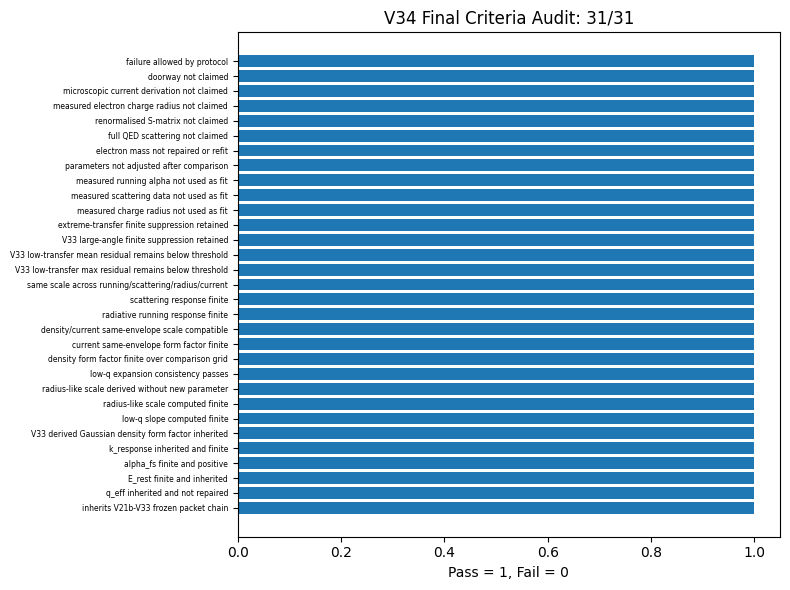

Output directory: /content/ecsm_electron_like_unified_form_factor_radius_current_radiative_v34_out
Zip file: /content/ecsm_electron_like_unified_form_factor_radius_current_radiative_v34_out.zip


,file
0,density_current_form_factor_consistency_summar...
1,density_current_form_factor_consistency_v34.csv
2,fig_v34_density_current_form_factor_consistenc...
3,fig_v34_final_unified_criteria_audit.png
4,fig_v34_low_q_form_factor_slope_audit.png
5,fig_v34_radius_like_scale_summary.png
6,fig_v34_running_response_same_scale_audit.png
7,fig_v34_same_scale_consistency_across_sectors.png
8,fig_v34_scattering_suppression_same_scale.png
9,final_unified_form_factor_radius_current_radia...


In [ ]:
plt.figure(figsize=(8, 6))
plot_df = criteria_df.copy()
plot_df["status"] = plot_df["pass"].astype(int)
plt.barh(np.arange(len(plot_df)), plot_df["status"])
plt.yticks(np.arange(len(plot_df)), plot_df["criterion"], fontsize=5.5)
plt.xlabel("Pass = 1, Fail = 0")
plt.title(f"V34 Final Criteria Audit: {n_pass}/{n_criteria}")
plt.tight_layout()
plt.savefig(OUT / "fig_v34_final_unified_criteria_audit.png", dpi=200)
plt.show()

manifest = pd.DataFrame({"file": sorted([p.name for p in OUT.iterdir()])})
manifest.to_csv(OUT / "output_manifest_v34.csv", index=False)

zip_path = BASE / "ecsm_electron_like_unified_form_factor_radius_current_radiative_v34_out.zip"
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        z.write(p, arcname=p.name)

print("Output directory:", OUT)
print("Zip file:", zip_path)
display(manifest)

## Cell 13 — Quick verification cell

In [ ]:
criteria_path = OUT / "unified_form_factor_radius_current_radiative_criteria_v34.csv"
summary_path = OUT / "run_summary_v34.json"
manifest_path = OUT / "output_manifest_v34.csv"

print("criteria exists:", criteria_path.exists())
print("run_summary exists:", summary_path.exists())
print("manifest exists:", manifest_path.exists())

if criteria_path.exists():
    display(pd.read_csv(criteria_path))

if summary_path.exists():
    print(json.dumps(json.loads(summary_path.read_text()), indent=2))

criteria exists: True
run_summary exists: True
manifest exists: True


,criterion,value,pass
0,inherits V21b-V33 frozen packet chain,1.000000e+00,True
1,q_eff inherited and not repaired,6.964280e-04,True
2,E_rest finite and inherited,5.140699e+02,True
3,alpha_fs finite and positive,7.297353e-03,True
4,k_response inherited and finite,5.140699e+03,True
5,V33 derived Gaussian density form factor inher...,1.000000e+00,True
6,low-q slope computed finite,-6.306733e-09,True
7,radius-like scale computed finite,3.838524e+01,True
8,radius-like scale derived without new parameter,0.000000e+00,True
9,low-q expansion consistency passes,5.179346e-05,True


{
  "run_label": "V34_unified_form_factor_radius_current_radiative_audit",
  "final_label": "PASS_UNIFIED_FORM_FACTOR_RADIUS_CURRENT_RADIATIVE_AUDIT",
  "n_pass": 31,
  "n_criteria": 31,
  "q_eff": -0.9993035720499918,
  "E_rest_keV_from_V21b": 514.0698767738036,
  "alpha_fs_input": 0.0072973525692838015,
  "k_response_keV": 5140.698767738036,
  "r_rms_fm_from_low_q_slope": 38.385244752791856,
  "slope_dF_dq2_at_zero_keV_minus2": -6.306732888797488e-09,
  "density_current_max_relative_difference": 0.0,
  "max_fractional_scale_mismatch": 0.0,
  "v33_low_transfer_max_shape_relative_difference": 0.02517755452141679,
  "v33_low_transfer_mean_shape_relative_difference": 0.0035746506191918566,
  "v33_fixed_grid_qmax_ratio": 0.21699058047365105,
  "extreme_transfer_cross_section_ratio_at_1e8_keV": 9.261851211544184e-305,
  "measured_charge_radius_used_as_fit": false,
  "measured_scattering_data_used_as_fit": false,
  "parameters_adjusted_after_comparison": false,
  "doorway_claimed": false,
 